In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from pathlib import Path

In [5]:
nri_long = pd.read_csv('../data/NRI_Long.csv', index_col=0)
nri_wide = pd.read_csv('../data/NRI_Wide.csv', index_col=0)

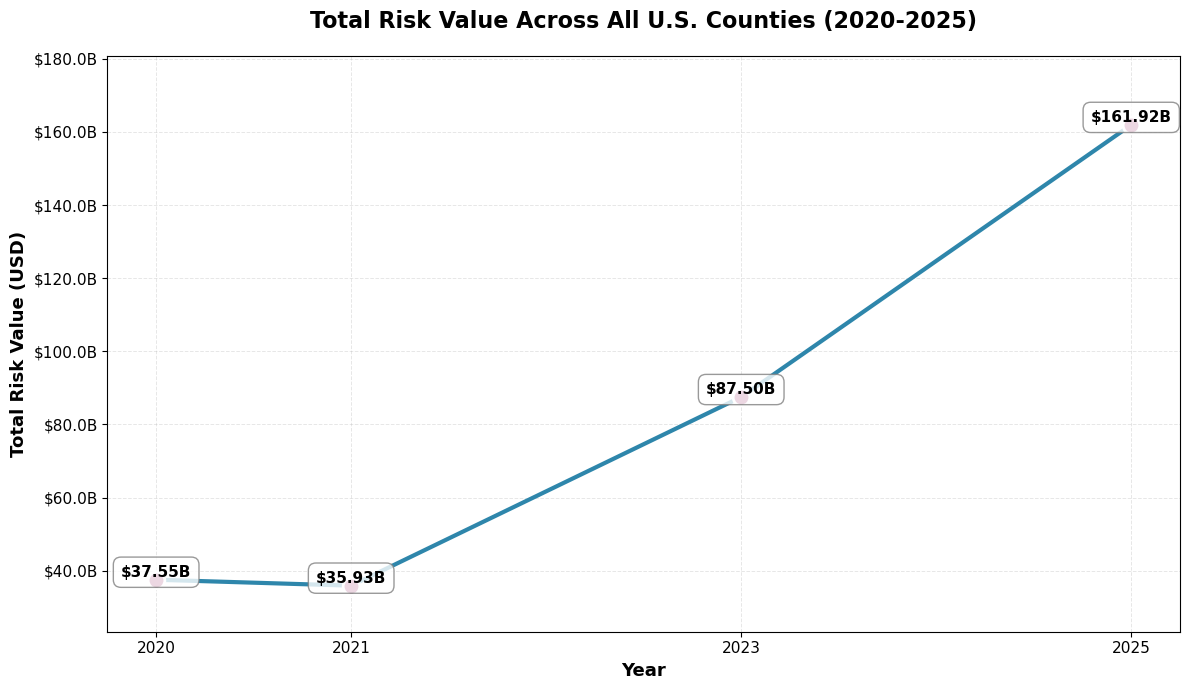

In [6]:
# Calculate total risk for each year
total_risk = {
    2020: nri_wide['risk_val_2020'].sum(),
    2021: nri_wide['risk_val_2021'].sum(),
    2023: nri_wide['risk_val_2023'].sum(),
    2025: nri_wide['risk_val_2025'].sum()
}

# Convert to lists for plotting
years = list(total_risk.keys())
total_risk = list(total_risk.values())

plt.figure(figsize=(12, 7))

# Plot the line
plt.plot(years, total_risk, 
         marker='o',           # Circle markers at each point
         markersize=12,        # Size of markers
         linewidth=3,          # Thickness of line
         color='#2E86AB',      # Nice blue color
         markerfacecolor='#A23B72',  # Different color for markers
         markeredgewidth=2,
         markeredgecolor='white')

# Add value labels on each point
for year, value in zip(years, total_risk):
    plt.text(year, value, 
             f'${value/1e9:.2f}B',  # Format as billions
             ha='center', 
             va='bottom',
             fontsize=11,
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

# Styling
plt.title('Total Risk Value Across All U.S. Counties (2020-2025)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Total Risk Value (USD)', fontsize=13, fontweight='bold')

# Format y-axis to show billions
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e9:.1f}B'))

# Add grid for readability
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Set x-axis to only show our years
plt.xticks(years, fontsize=11)
plt.yticks(fontsize=11)

# Add some padding to y-axis
y_range = max(total_risk) - min(total_risk)
plt.ylim(min(total_risk) - y_range*0.1, max(total_risk) + y_range*0.15)

# Tight layout
plt.tight_layout()

plt.show()

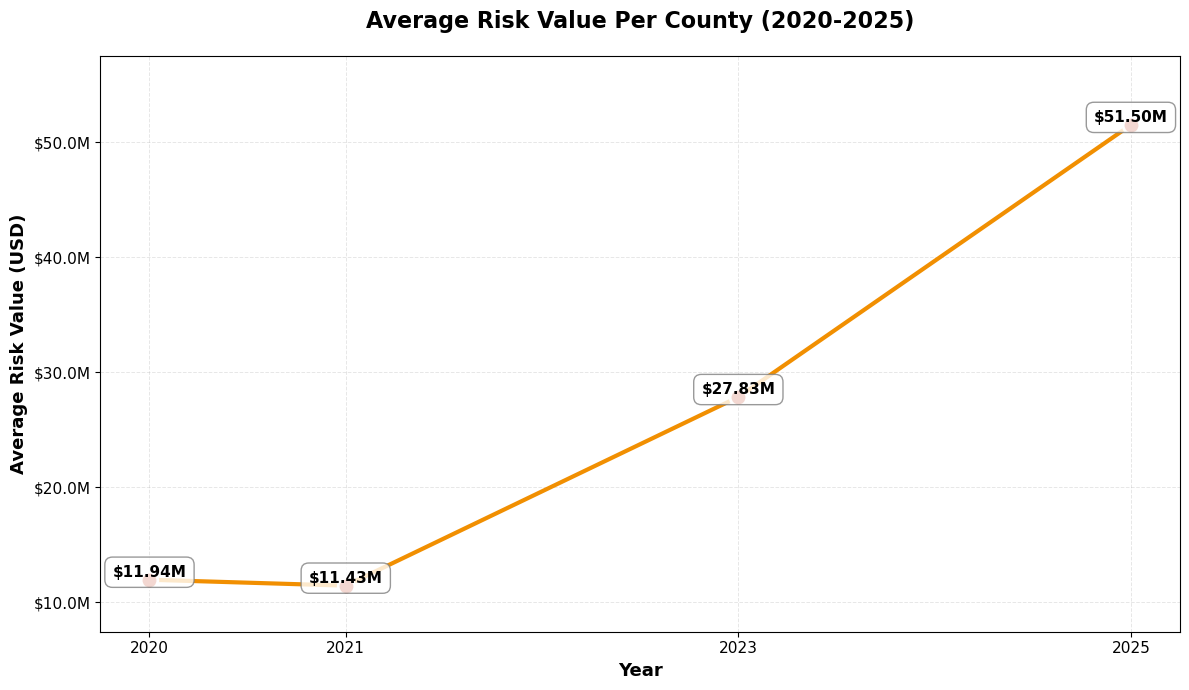

In [7]:
avg_risk_by_year = {
    2020: nri_wide['risk_val_2020'].mean(),
    2021: nri_wide['risk_val_2021'].mean(),
    2023: nri_wide['risk_val_2023'].mean(),
    2025: nri_wide['risk_val_2025'].mean()
}

years_avg = list(avg_risk_by_year.keys())
avg_risk = list(avg_risk_by_year.values())

plt.figure(figsize=(12, 7))
plt.plot(years_avg, avg_risk, 
         marker='o',
         markersize=12,
         linewidth=3,
         color='#F18F01',      # Orange color
         markerfacecolor='#C73E1D',
         markeredgewidth=2,
         markeredgecolor='white')

# Add value labels
for year, value in zip(years_avg, avg_risk):
    plt.text(year, value, 
             f'${value/1e6:.2f}M',  # Format as millions
             ha='center', 
             va='bottom',
             fontsize=11,
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8))

plt.title('Average Risk Value Per County (2020-2025)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Average Risk Value (USD)', fontsize=13, fontweight='bold')

# Format y-axis to show millions
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
plt.xticks(years_avg, fontsize=11)
plt.yticks(fontsize=11)

y_range = max(avg_risk) - min(avg_risk)
plt.ylim(min(avg_risk) - y_range*0.1, max(avg_risk) + y_range*0.15)

plt.tight_layout()
plt.show()

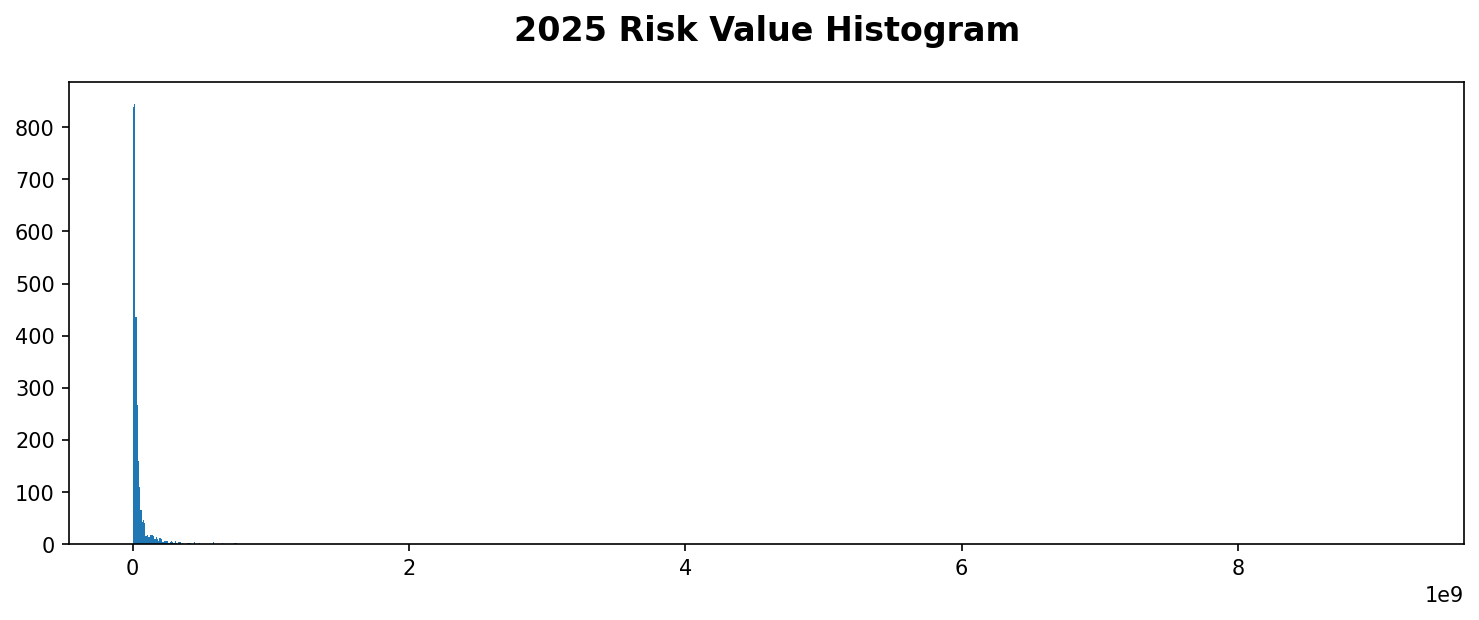

In [10]:
fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ymin,ymax = ax.get_ylim() 
plt.title('2025 Risk Value Histogram', 
          fontsize=16, fontweight='bold', pad=20)
ax.hist(nri_wide.risk_val_2025, bins=1000)
ax.vlines(x=nri_wide.risk_val_2025.mean(),ymin=ymin,ymax=ymax,colors='r',linestyles='--',label='Avg')
plt.show()

In [12]:
nri_wide.style.format({"risk_val_2025": "{:,}"})
nri_wide[nri_wide['risk_val_2025'] > 1000000000].sort_values('risk_val_2025',ascending=False)

,nri_id,statefips,countyfips,stateabbrv,county,risk_val_2025,eal_valt_2025,sovi_score_2025,resl_score_2025,crf_value_2025,...,risk_val_2021,eal_valt_2021,sovi_score_2021,resl_score_2021,crf_value_2021,risk_val_2020,eal_valt_2020,sovi_score_2020,resl_score_2020,crf_value_2020
206,C06037,6,37,CA,Los Angeles,9.180158e+09,7.601846e+09,55.375318,13.549618,1.207622,...,2.107594e+09,1.433566e+09,44.895546,51.892200,1.470177,2.067971e+09,1.406614e+09,44.895546,51.892200,1.470177
621,C17031,17,31,IL,Cook,2.957063e+09,2.424304e+09,61.736641,73.282443,1.219757,...,2.311134e+08,1.755249e+08,43.042964,54.735598,1.316699,2.397367e+08,1.820740e+08,43.042964,54.735598,1.316699
2634,C48201,48,201,TX,Harris,2.947094e+09,2.217702e+09,67.938931,17.875318,1.328895,...,1.443774e+09,1.181227e+09,38.904218,52.227802,1.222266,7.389618e+07,6.045833e+07,38.904218,52.227802,1.222266
220,C06065,6,65,CA,Riverside,2.304891e+09,2.265638e+09,33.333333,13.040712,1.017326,...,5.301808e+08,4.049030e+08,40.362633,51.501598,1.309402,4.509519e+08,3.443953e+08,40.362633,51.501598,1.309402
105,C04013,4,13,AZ,Maricopa,2.118483e+09,2.195562e+09,27.099237,18.034351,0.964893,...,5.268268e+07,4.410347e+07,37.958218,51.866998,1.194525,1.265500e+08,1.059417e+08,37.958218,51.866998,1.194525
223,C06071,6,71,CA,San Bernardino,2.104012e+09,2.075100e+09,33.206107,20.069975,1.013933,...,4.447540e+08,3.528855e+08,40.283800,53.054800,1.260335,4.002674e+08,3.175880e+08,40.283800,53.054800,1.260335
217,C06059,6,59,CA,Orange,1.822512e+09,1.926467e+09,24.936387,16.316794,0.946039,...,3.071661e+08,3.389863e+08,28.813559,52.104602,0.906131,3.072696e+08,3.391005e+08,28.813559,52.104602,0.906131
188,C06001,6,1,CA,Alameda,1.776525e+09,1.884810e+09,27.480916,91.157761,0.942549,...,3.559766e+08,4.015266e+08,28.852976,53.484202,0.886558,3.610067e+08,4.072003e+08,28.852976,53.484202,0.886558
230,C06085,6,85,CA,Santa Clara,1.686687e+09,1.965274e+09,17.239186,72.614504,0.858245,...,2.720342e+08,4.262598e+08,15.845487,52.772998,0.638189,2.794440e+08,4.378705e+08,15.845487,52.772998,0.638189
224,C06073,6,73,CA,San Diego,1.462271e+09,1.539181e+09,24.809160,8.301527,0.950032,...,3.199322e+08,3.176746e+08,32.203390,51.603398,1.007107,2.503905e+08,2.486236e+08,32.203390,51.603398,1.007107


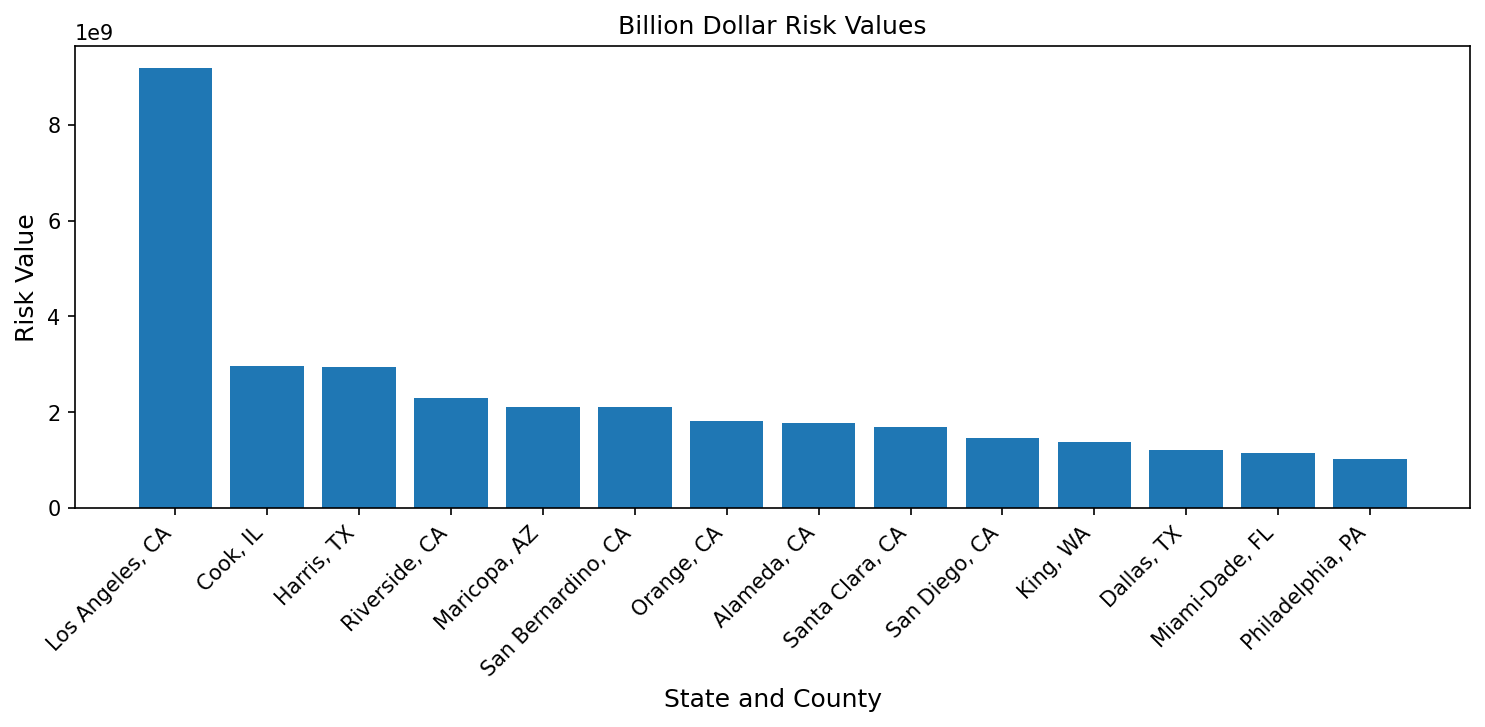

In [13]:
bil_25 = nri_wide[nri_wide['risk_val_2025'] > 1000000000].sort_values('risk_val_2025',ascending=False)
bil_25['county_state'] = bil_25.county + ', ' + bil_25.stateabbrv

plt.figure(figsize=(12, 4), dpi=150)
plt.bar(bil_25['county_state'],bil_25.risk_val_2025, linewidth=2)
plt.xticks(rotation=45,ha='right')
plt.title("Billion Dollar Risk Values")
plt.ylabel("Risk Value", fontsize=12)
plt.xlabel("State and County", fontsize=12)
plt.show()

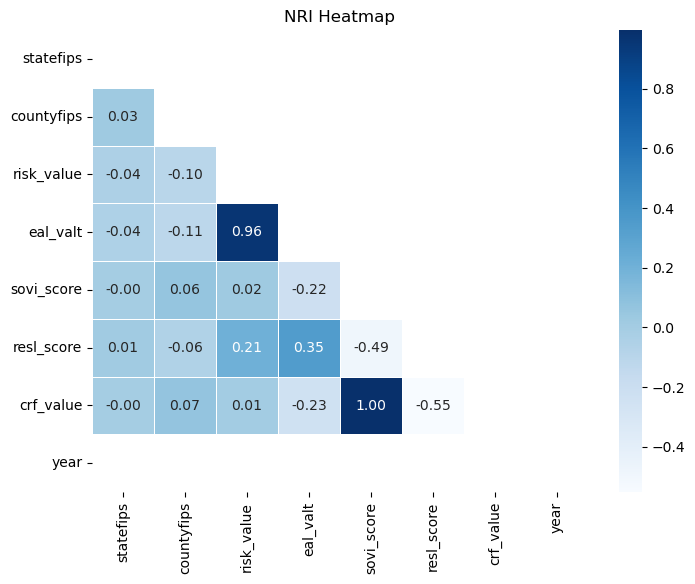

In [15]:
nri_25 = nri_long[nri_long['year'] == 2025]
correlation_matrix = nri_25.corr(method='spearman',numeric_only=True) # numeric_only=True to handle non-numeric columns
correlation_matrix

mask = np.ones_like(correlation_matrix, dtype=bool)
mask = np.triu(mask)
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, mask=mask)
plt.title('NRI Heatmap')
plt.show()

In [17]:
sovi = nri_25.sovi_score.describe()
resl = nri_25.resl_score.describe()
resl2 = nri_25.resl_score.describe()
crf = nri_25.crf_value.describe()
resil = pd.concat([sovi,resl2,resl,crf],axis=1)
resil

,sovi_score,resl_score,resl_score,crf_value
count,3144.000000,3144.000000,3144.000000,3144.000000
mean,50.623193,50.015903,50.015903,1.166906
std,27.997643,28.872104,28.872104,0.311924
min,10.623410,0.031807,0.031807,0.515445
25%,25.047710,25.023855,25.023855,0.933219
50%,50.031807,50.015903,50.015903,1.134112
75%,75.031807,75.007952,75.007952,1.387725
max,100.000000,100.000000,100.000000,2.000000


In [20]:
nri_20 = nri_long[nri_long['year'] == 2020]
sovi = nri_20.sovi_score.describe()
resl = nri_20.resl_score.describe()
crf = nri_20.crf_value.describe()
resil = pd.concat([sovi,resl,crf],axis=1)
resil

,sovi_score,resl_score,crf_value
count,3144.000000,3144.000000,3144.000000
mean,38.350401,54.590881,1.166834
std,11.143126,2.941943,0.311806
min,0.010000,41.189398,0.515450
25%,31.878203,52.648000,0.933357
50%,38.332676,54.657700,1.133837
75%,44.461963,56.745800,1.387530
max,100.000000,64.673600,2.000000


In [21]:
nri_wide['risk_change'] = nri_wide['risk_val_2025'] - nri_wide['risk_val_2020']
nri_wide.head(10)

,nri_id,statefips,countyfips,stateabbrv,county,risk_val_2025,eal_valt_2025,sovi_score_2025,resl_score_2025,crf_value_2025,...,eal_valt_2021,sovi_score_2021,resl_score_2021,crf_value_2021,risk_val_2020,eal_valt_2020,sovi_score_2020,resl_score_2020,crf_value_2020,risk_change
0,C01001,1,1,AL,Autauga,2.051090e+07,1.975657e+07,38.040712,55.120865,1.038181,...,2.656700e+06,25.857312,55.529800,0.785720,2.602012e+06,3.311627e+06,25.857312,55.529800,0.785720,1.790889e+07
1,C01003,1,3,AL,Baldwin,2.532687e+08,2.373912e+08,44.243003,93.002545,1.066884,...,1.179273e+07,34.292471,54.759202,1.009514,1.834143e+07,1.816858e+07,34.292471,54.759202,1.009514,2.349273e+08
2,C01005,1,5,AL,Barbour,1.599858e+07,8.923878e+06,96.374046,11.164122,1.792783,...,3.533816e+06,34.686638,50.781998,1.105235,3.329980e+06,3.012916e+06,34.686638,50.781998,1.105235,1.266860e+07
3,C01007,1,7,AL,Bibb,1.267247e+07,8.993704e+06,75.254453,22.169211,1.409038,...,1.756287e+06,21.482065,51.807600,0.730199,1.564590e+06,2.142689e+06,21.482065,51.807600,0.730199,1.110788e+07
4,C01009,1,9,AL,Blount,2.870536e+07,2.129467e+07,69.338422,15.648855,1.348007,...,5.954617e+06,29.720142,53.357400,0.909934,4.141449e+06,4.551373e+06,29.720142,53.357400,0.909934,2.456391e+07
5,C01011,1,11,AL,Bullock,8.886364e+06,5.129262e+06,97.550891,33.142494,1.732484,...,7.621959e+05,37.879385,49.789800,1.264218,1.217326e+06,9.629083e+05,37.879385,49.789800,1.264218,7.669038e+06
6,C01013,1,13,AL,Butler,1.489462e+07,9.390471e+06,91.762087,50.031807,1.586142,...,4.115058e+06,49.940875,52.902598,1.593575,5.765549e+06,3.617997e+06,49.940875,52.902598,1.593575,9.129069e+06
7,C01015,1,15,AL,Calhoun,7.775160e+07,5.378140e+07,81.488550,48.441476,1.445697,...,1.522439e+07,38.391801,54.929400,1.133424,1.206899e+07,1.064826e+07,38.391801,54.929400,1.133424,6.568261e+07
8,C01017,1,17,AL,Chambers,1.563669e+07,1.090275e+07,79.421120,41.444020,1.434197,...,1.704562e+06,43.121797,53.372202,1.365234,3.789366e+06,2.775616e+06,43.121797,53.372202,1.365234,1.184732e+07
9,C01019,1,19,AL,Cherokee,2.426144e+07,1.612793e+07,81.806616,16.125954,1.504312,...,3.995858e+06,32.597556,51.344600,1.020175,3.892760e+06,3.815777e+06,32.597556,51.344600,1.020175,2.036868e+07


In [22]:
change_check = nri_wide[["nri_id","stateabbrv","county","risk_change"]].copy()
change_check["county_st"] = change_check["county"] + ', ' + change_check["stateabbrv"]

change_check = change_check[~change_check['nri_id'].str.contains('C09013')]

change_check = change_check.sort_values(by='risk_change',ascending=False)

change_check.risk_change.describe()

count    3.144000e+03
mean     3.955697e+07
std      1.781608e+08
min     -1.070330e+08
25%      4.858194e+06
50%      1.139169e+07
75%      2.644977e+07
max      7.112188e+09
Name: risk_change, dtype: float64

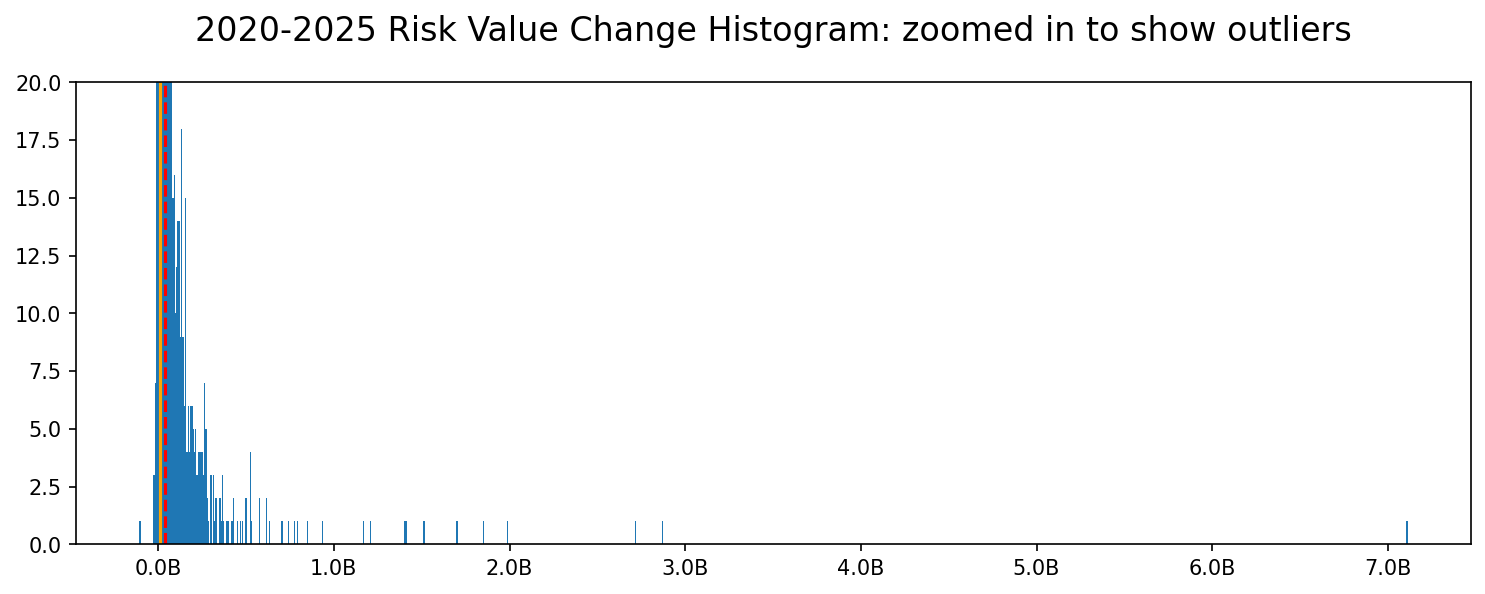

In [23]:
sqrt = round(3145**0.5)
def billions_formatter(x, pos):
    return f'{x / 1e9:.1f}B'

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
ymin,ymax = 0,20 

plt.title('2020-2025 Risk Value Change Histogram: zoomed in to show outliers', 
          fontsize=16, pad=20)
ax.hist(change_check.risk_change, bins=1000)
ax.vlines(x=change_check.risk_change.mean(),ymin=0,ymax=ymax,colors='r',linestyles='--',label='Avg')
ax.vlines(x=change_check.risk_change.median(),ymin=0,ymax=ymax,colors='orange',linestyles='-',label='50M')
ax.set_ylim(ymin,ymax)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(billions_formatter))
plt.show()

98% of counties are under 38M risk value increase from 2020-25. 80% of counties had a 5% increase or less. 

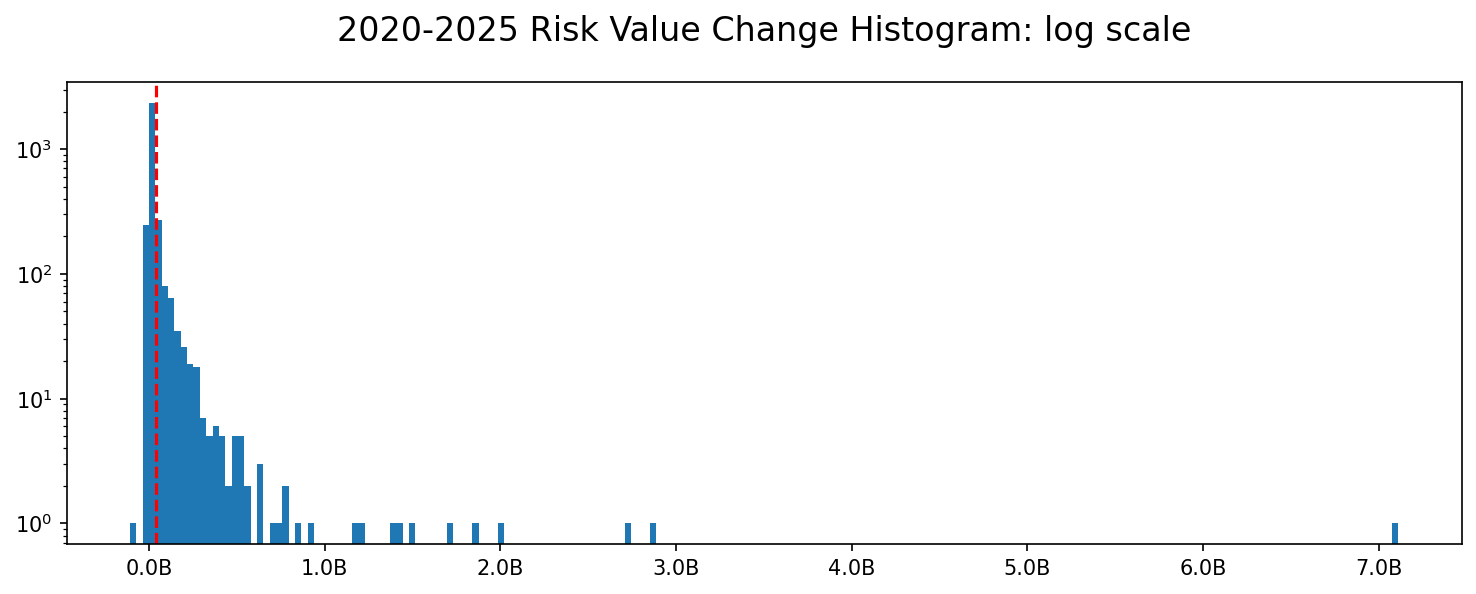

In [24]:
sqrt = round(3145**0.5)
def billions_formatter(x, pos):
    return f'{x / 1e9:.1f}B'

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)


plt.title('2020-2025 Risk Value Change Histogram: log scale', 
          fontsize=16, pad=20)
ax.hist(change_check.risk_change, bins=200)
ax.set_yscale('log')
ymin,ymax = ax.get_ylim() 
ax.vlines(x=change_check.risk_change.mean(),ymin=ymin,ymax=ymax,colors='r',linestyles='--',label='Avg')
# ax.vlines(x=change_check.risk_change.median(),ymin=ymin,ymax=ymax,colors='orange',linestyles='-',label='50M')
# ax.set_ylim(ymin,ymax)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(billions_formatter))
plt.show()

In [25]:
change_check[change_check['risk_change'] > 1000000000]

,nri_id,stateabbrv,county,risk_change,county_st
206,C06037,CA,Los Angeles,7.112188e+09,"Los Angeles, CA"
2634,C48201,TX,Harris,2.873198e+09,"Harris, TX"
621,C17031,IL,Cook,2.717326e+09,"Cook, IL"
105,C04013,AZ,Maricopa,1.991933e+09,"Maricopa, AZ"
220,C06065,CA,Riverside,1.853939e+09,"Riverside, CA"
223,C06071,CA,San Bernardino,1.703745e+09,"San Bernardino, CA"
217,C06059,CA,Orange,1.515242e+09,"Orange, CA"
188,C06001,CA,Alameda,1.415519e+09,"Alameda, CA"
230,C06085,CA,Santa Clara,1.407243e+09,"Santa Clara, CA"
224,C06073,CA,San Diego,1.211881e+09,"San Diego, CA"


In [26]:
print('% Risk Value change under 35M: ',len(change_check[change_check['risk_change'] < 350000000])/3145)
print('% Risk Value increase: ',len(change_check[change_check['risk_change'] > 0])/3145)

% Risk Value change under 35M:  0.9847376788553259
% Risk Value increase:  0.9596184419713831


In [28]:
change_check['%_risk_change'] = change_check['risk_change']/nri_wide['risk_val_2020']
change_check['%_risk_change'].describe()

count    3144.000000
mean        3.534055
std         4.204099
min        -0.928758
25%         1.312278
50%         2.573191
75%         4.440685
max       109.496502
Name: %_risk_change, dtype: float64

In [29]:
print('% Risk Value change < 5%: ',len(change_check[change_check['%_risk_change'] < 5])/3145)

% Risk Value change < 5%:  0.7933227344992051


In [30]:
change_check[change_check['risk_change'] > 350000000]

,nri_id,stateabbrv,county,risk_change,county_st,%_risk_change
206,C06037,CA,Los Angeles,7.112188e+09,"Los Angeles, CA",3.439211
2634,C48201,TX,Harris,2.873198e+09,"Harris, TX",38.881547
621,C17031,IL,Cook,2.717326e+09,"Cook, IL",11.334627
105,C04013,AZ,Maricopa,1.991933e+09,"Maricopa, AZ",15.740291
220,C06065,CA,Riverside,1.853939e+09,"Riverside, CA",4.111168
223,C06071,CA,San Bernardino,1.703745e+09,"San Bernardino, CA",4.256516
217,C06059,CA,Orange,1.515242e+09,"Orange, CA",4.931311
188,C06001,CA,Alameda,1.415519e+09,"Alameda, CA",3.921032
230,C06085,CA,Santa Clara,1.407243e+09,"Santa Clara, CA",5.035868
224,C06073,CA,San Diego,1.211881e+09,"San Diego, CA",4.839963
